In [10]:
import pandas as pd
import seaborn as sns
from imblearn.over_sampling import SMOTE
from collections import Counter
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.metrics import (classification_report, recall_score, PrecisionRecallDisplay, confusion_matrix, average_precision_score, 
                             precision_recall_curve, roc_auc_score, cohen_kappa_score)
from sklearn.model_selection import train_test_split, GridSearchCV, RepeatedStratifiedKFold
from imblearn.pipeline import Pipeline
import numpy as np
from sklearn.inspection import permutation_importance

## Data preparation

In [11]:
# =====================
# 1. Prepare Data
# =====================
df = pd.read_csv(r"C:\Users\dbastola2022\OneDrive - Florida Atlantic University\Academics\Research\Malnutrition\MICS\malnutrition\Dataset\ch.csv") #Local
df.head(2)

X = df.drop(columns=['status'])
y = df['status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

# print("Before SMOTE:", Counter(y_train))
# print("After SMOTE:", Counter(y_train_sm))

## Base Model

In [12]:
# =====================
# 2. Base Model with SMOTE outside pipeline
# =====================
base_svm = SVC(kernel='linear', probability=True, random_state=42)
base_svm.fit(X_train_sm, y_train_sm)

y_pred_base = base_svm.predict(X_test)
y_proba_base = base_svm.predict_proba(X_test)[:, 1]
y_train_pred_base = base_svm.predict(X_train_sm)

# Evaluation
print(confusion_matrix(y_test, y_pred_base))
print("------------------------------------------------------")
print(classification_report(y_test, y_pred_base, digits=3))
print("------------------------------------------------------")
print(f"Test Average Precision: {average_precision_score(y_test, y_proba_base):.3f}")
print(f"Test AUC: {roc_auc_score(y_test, y_proba_base):.3f}")
print(f"Test Cohen's Kappa: {cohen_kappa_score(y_test, y_pred_base):.3f}")
print(f"Training recall: {recall_score(y_train_sm, y_train_pred_base):.3f}")

[[532 175]
 [151 453]]
------------------------------------------------------
              precision    recall  f1-score   support

           0      0.779     0.752     0.765       707
           1      0.721     0.750     0.735       604

    accuracy                          0.751      1311
   macro avg      0.750     0.751     0.750      1311
weighted avg      0.752     0.751     0.752      1311

------------------------------------------------------
Test Average Precision: 0.760
Test AUC: 0.799
Test Cohen's Kappa: 0.501
Training recall: 0.735


## Tuned SVM

In [13]:
# =====================
# 3. Tuned SVM using Pipeline + GridSearchCV
# =====================
pipe = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('svm', SVC(probability=True, random_state=42))
])

param_grid = {
    'svm__C': [1, 5, 10],
    'svm__kernel': ['linear', 'rbf'],
    'svm__gamma': ['scale', 'auto']  # only for rbf/poly
}

grid_svm = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring='recall',
    cv=RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42),
    n_jobs=-1,
    verbose=2
)

grid_svm.fit(X_train, y_train)  # SMOTE happens inside pipeline

# Evaluation
best_svm = grid_svm.best_estimator_
y_pred_tuned = best_svm.predict(X_test)
y_proba_tune = best_svm.predict_proba(X_test)[:, 1]
y_train_pred_tuned = best_svm.predict(X_train)

print("Best Parameters:", grid_svm.best_params_)
print("------------------------------------------------------")
print(confusion_matrix(y_test, y_pred_tuned))
print("------------------------------------------------------")
print(classification_report(y_test, y_pred_tuned, digits=3))
print("------------------------------------------------------")
print(f"Test Average Precision: {average_precision_score(y_test, y_proba_tune):.3f}")
print(f"Test AUC: {roc_auc_score(y_test, y_proba_tune):.3f}")
print(f"Test Cohen's Kappa: {cohen_kappa_score(y_test, y_pred_tuned):.3f}")
print(f"Training recall: {recall_score(y_train, y_train_pred_tuned):.3f}")


Fitting 15 folds for each of 12 candidates, totalling 180 fits
Best Parameters: {'svm__C': 5, 'svm__gamma': 'scale', 'svm__kernel': 'linear'}
------------------------------------------------------
[[532 175]
 [151 453]]
------------------------------------------------------
              precision    recall  f1-score   support

           0      0.779     0.752     0.765       707
           1      0.721     0.750     0.735       604

    accuracy                          0.751      1311
   macro avg      0.750     0.751     0.750      1311
weighted avg      0.752     0.751     0.752      1311

------------------------------------------------------
Test Average Precision: 0.760
Test AUC: 0.799
Test Cohen's Kappa: 0.501
Training recall: 0.734


### 95% CI on Recall

Recall 95% CI: (0.715, 0.784)


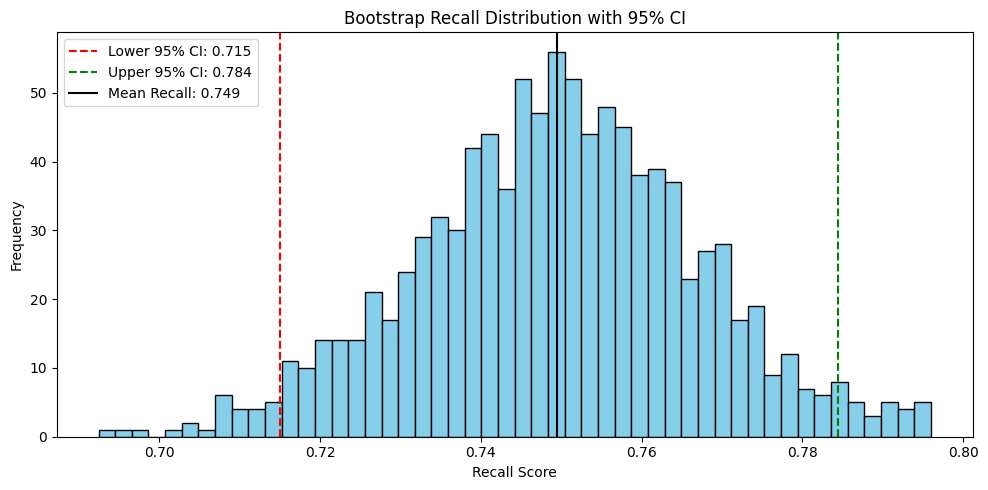

In [14]:
def bootstrap_ci_recall_distribution(y_true, y_pred_func, X, n_bootstraps=1000, alpha=0.95):
    rng = np.random.RandomState(42)
    bootstrapped_scores = []
    n = len(y_true)
    for _ in range(n_bootstraps):
        indices = rng.choice(np.arange(n), size=n, replace=True)
        if len(np.unique(y_true.iloc[indices])) < 2:
            continue
        score = recall_score(y_true.iloc[indices], y_pred_func(X.iloc[indices]))
        bootstrapped_scores.append(score)
    sorted_scores = np.sort(bootstrapped_scores)
    lower = np.percentile(sorted_scores, ((1-alpha)/2)*100)
    upper = np.percentile(sorted_scores, (alpha + (1-alpha)/2)*100)
    return bootstrapped_scores, lower, upper

# scores
recall_scores, lower_ci, upper_ci = bootstrap_ci_recall_distribution(
    y_test.reset_index(drop=True), 
    best_svm.predict, 
    X_test.reset_index(drop=True)
)

print(f"Recall 95% CI: ({lower_ci:.3f}, {upper_ci:.3f})")

# plot
plt.figure(figsize=(10, 5))
plt.hist(recall_scores, bins=50, color='skyblue', edgecolor='black')
plt.axvline(lower_ci, color='red', linestyle='--', label=f"Lower 95% CI: {lower_ci:.3f}")
plt.axvline(upper_ci, color='green', linestyle='--', label=f"Upper 95% CI: {upper_ci:.3f}")
plt.axvline(np.mean(recall_scores), color='black', linestyle='-', label=f"Mean Recall: {np.mean(recall_scores):.3f}")
plt.title("Bootstrap Recall Distribution with 95% CI")
plt.xlabel("Recall Score")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

### Feature importance

                            Feature  Importance
1                      child_weight    2.123610
0                         child_age    1.230492
5                         child_sex    0.478169
12              province_Province 2    0.323723
10        province_Karnali Province    0.290100
7                  health_insurance    0.262508
4                              area    0.175132
11              province_Province 1    0.173355
3                fever_last_2_weeks    0.125282
6                  mother_education    0.119916
14  province_Sudoorpaschim Province    0.104322
9         province_Gandaki Province    0.100404
8                      wealth_index    0.065213
2            diarrhoea_last_2_weeks    0.015740
13              province_Province 5    0.003388


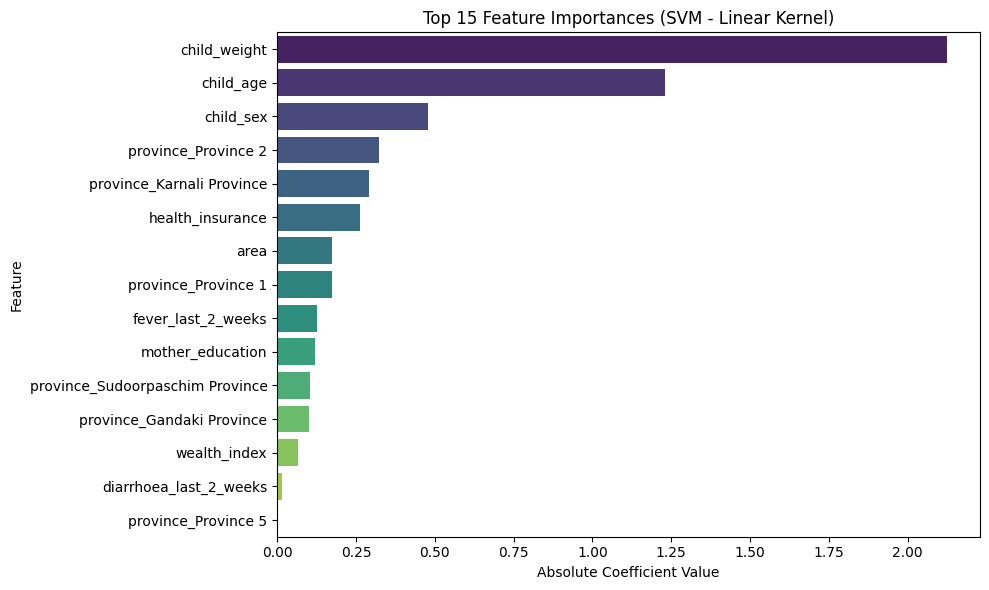

In [15]:
# Extract the linear SVM model
svm_model = best_svm.named_steps['svm']

# Get feature names from your training data
feature_names = X_train.columns

# Get coefficients and compute absolute importance
coef = svm_model.coef_[0]
importance = np.abs(coef)

# Create a DataFrame of feature importances
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

# Show top features
print(importance_df.head(15))

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(
    data=importance_df.head(15),
    x='Importance',
    y='Feature',
    hue='Feature',                # Assign hue
    palette='viridis',
    dodge=False,                 # Prevent overlapping bars
    legend=False                 # Suppress legend if unnecessary
)
plt.title('Top 15 Feature Importances (SVM - Linear Kernel)')
plt.xlabel('Absolute Coefficient Value')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


#### Feature importance with coefficients

                            Feature  Base Importance  Tuned Importance
1                      child_weight         2.111217          2.123610
0                         child_age         1.223427          1.230492
5                         child_sex         0.471567          0.478169
12              province_Province 2         0.324081          0.323723
10        province_Karnali Province         0.288633          0.290100
7                  health_insurance         0.256907          0.262508
4                              area         0.175547          0.175132
11              province_Province 1         0.182827          0.173355
3                fever_last_2_weeks         0.120606          0.125282
6                  mother_education         0.118454          0.119916
14  province_Sudoorpaschim Province         0.102765          0.104322
9         province_Gandaki Province         0.111489          0.100404
8                      wealth_index         0.065452          0.065213
2     

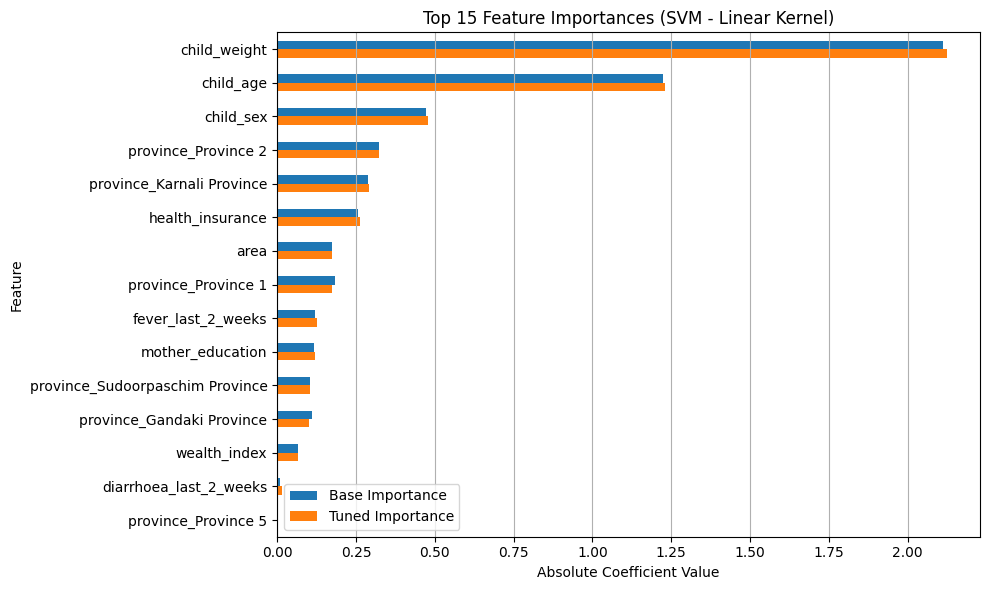

In [16]:
# Get feature names
feature_names = X_train.columns

# 2. Extract the Random Forest model from the pipeline
svm_tuned_model = best_svm.named_steps['svm'] # from pipeline
svm_base_model = base_svm # directly used without pipeline

# Extract coefficients (works for linear kernels)
coef_base = svm_base_model.coef_[0]
coef_tuned = svm_tuned_model.coef_[0]

# Create DataFrame with absolute coefficients
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Base Importance': np.abs(coef_base),
    'Tuned Importance': np.abs(coef_tuned)
}).sort_values(by='Tuned Importance', ascending=False)

print(importance_df)

# Feature importances horizontally
top_features = importance_df.set_index('Feature')

top_features.plot(kind='barh', figsize=(10, 6))
plt.title('Top 15 Feature Importances (SVM - Linear Kernel)')
plt.xlabel('Absolute Coefficient Value')
plt.ylabel('Feature')
plt.gca().invert_yaxis()
plt.grid(True, axis='x')
plt.tight_layout()
plt.show()


### Average precision plot

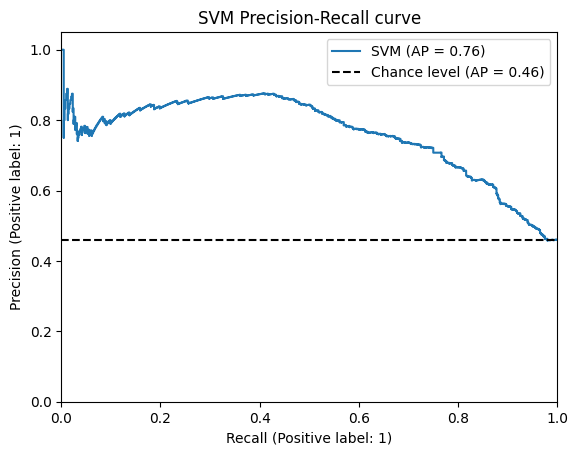

In [17]:
display = PrecisionRecallDisplay.from_estimator(
    best_svm,            # Trained model
    X_test,              # Test features
    y_test,              # True labels
    name="SVM",          # Name for legend
    plot_chance_level=True  # Automatically plots chance-level baseline
)

display.ax_.set_title("SVM Precision-Recall curve")
display.ax_.legend(loc='upper right')
display.ax_.set_xlim([0.0, 1.0])
display.ax_.set_ylim([0.0, 1.05])
plt.show()

### Additional

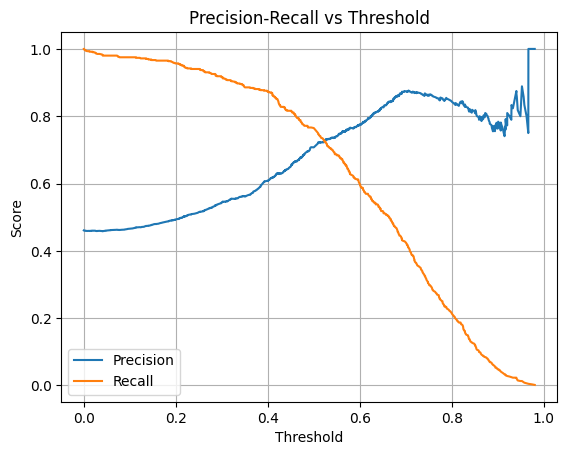

In [18]:
y_proba_tune = best_svm.predict_proba(X_test)[:, 1]       #Probabilities for class 1
precision, recall, thresholds = precision_recall_curve(y_test, y_proba_tune)

plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall vs Threshold')
plt.grid()
plt.legend()
plt.show()

In [19]:
# Apply custom threshold
y_proba_custom = (y_proba_tune >= 0.40).astype(int)
print(f'Classification Report: \n{classification_report(y_test, y_proba_custom, digits = 3)}\n')

Classification Report: 
              precision    recall  f1-score   support

           0      0.828     0.519     0.638       707
           1      0.608     0.874     0.717       604

    accuracy                          0.683      1311
   macro avg      0.718     0.697     0.678      1311
weighted avg      0.727     0.683     0.675      1311


